In [78]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

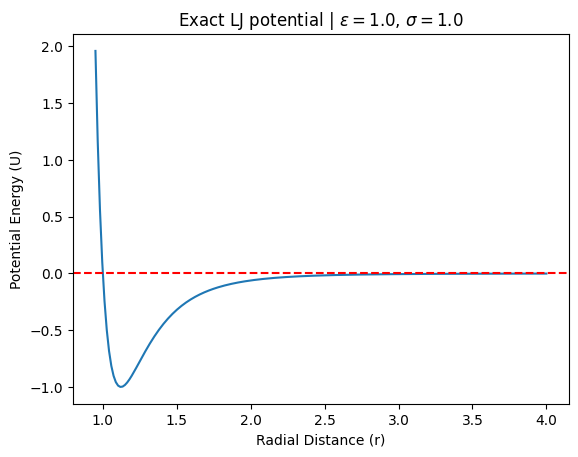

In [79]:
# generating data for LJ potential
ep = 1.0
sigma = 1.0
r = torch.linspace(0.95,4.0,200,requires_grad=True).reshape(-1,1)
with torch.no_grad():
    U_exact = 4*ep*((sigma/r)**12 - (sigma/r)**6)

# visualising the correct LJ potential
plt.plot(r.flatten().detach(),U_exact.flatten().detach())
plt.axhline(0,ls = '--',c='red')
plt.title(f'Exact LJ potential | $\epsilon = ${ep}, $\sigma = ${sigma}')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Potential Energy (U)')
plt.show()

In [80]:
# defining the NN model
# the model will take 'r' as input and return 'U'
model = nn.Sequential(
    nn.Linear(1,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [81]:
# loss function
def Loss(model,r):
    U = model(r)
    return torch.mean((U-U_exact)**2)

In [82]:
# optimizer
optim = torch.optim.Adam(model.parameters(),lr = 0.01)

In [83]:
# training the model
N_epochs = 100000
loss_arr = []
for epoch in range(N_epochs):
    loss = Loss(model,r)
    loss_arr.append(loss.item())
    loss.backward()
    optim.step()
    optim.zero_grad()

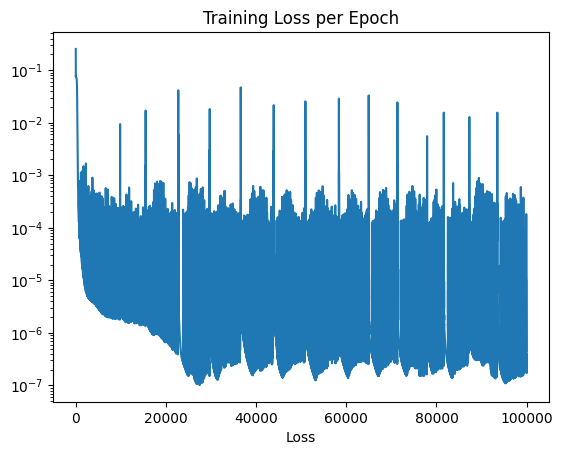

In [84]:
# visualising loss
plt.semilogy(loss_arr)
plt.xlabel('Epoch')
plt.xlabel('Loss')
plt.title('Training Loss per Epoch')
plt.show()

In [85]:
U_nn = model(r)

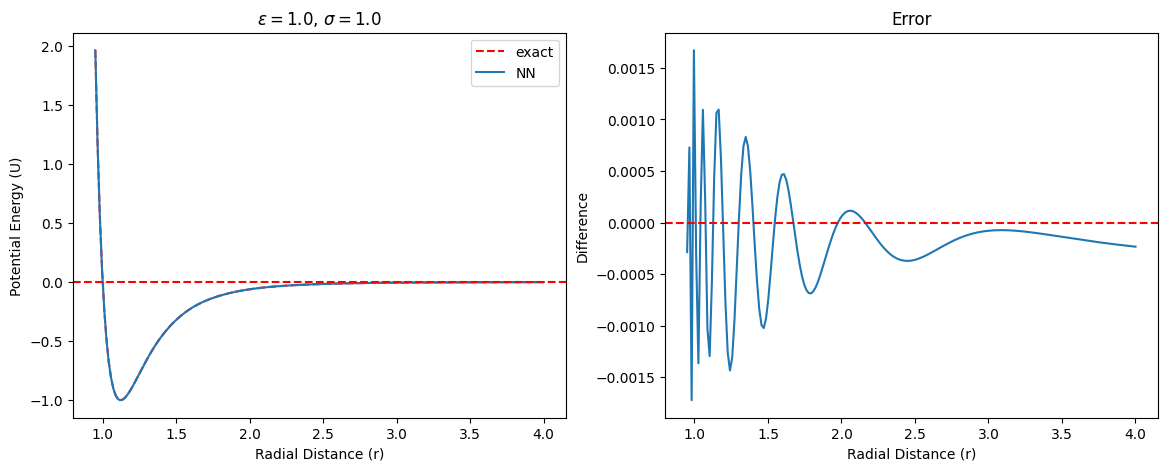

In [86]:
# visualising the correct and nn-predicted LJ potential

plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.plot(r.flatten().detach(),U_exact.flatten().detach(),c='red',ls = '--',label = 'exact')
plt.plot(r.flatten().detach(),U_nn.flatten().detach(),label = 'NN')
plt.axhline(0,ls = '--',c='red')
plt.title(f'$\epsilon = ${ep}, $\sigma = ${sigma}')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Potential Energy (U)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(r.flatten().detach(),(U_nn-U_exact).flatten().detach())
plt.axhline(0,ls = '--',c='red')
plt.title(f'Error')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Difference')
plt.show()

### Remarks :

1. ReLU activation performs badly on this problem. Loss cannot diminish after a threshold.

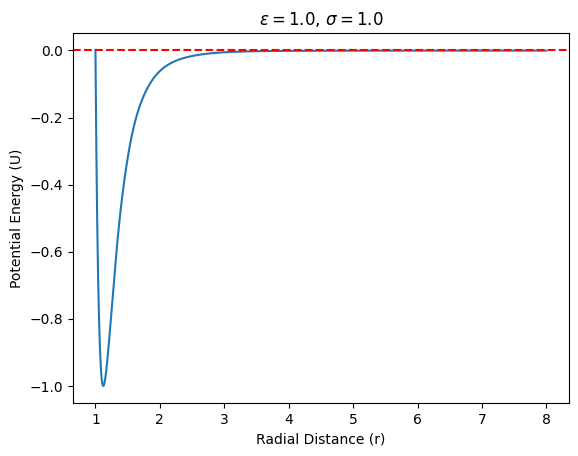

In [90]:
# beyond training region

r_beyond = torch.linspace(1.0,8.0,1000).reshape(-1,1)
y_beyond = model(r_beyond)
plt.plot(r_beyond.flatten().detach(),y_beyond.flatten().detach())
plt.axhline(0,c='red',ls = '--')
plt.title(f'$\epsilon = ${ep}, $\sigma = ${sigma}')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Potential Energy (U)')
plt.show()

### Comparing the Forces

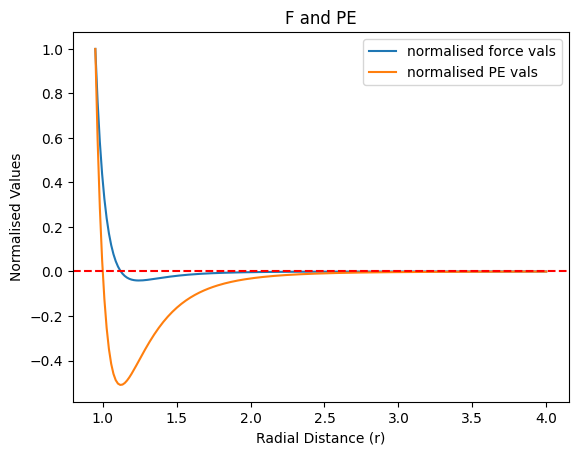

In [98]:
F_exact = 4*ep*(12*(sigma/r)**12/r - 6*(sigma/r)**6/r)
plt.plot(r.flatten().detach(),(F_exact/max(F_exact)).flatten().detach(),label = 'normalised force vals')
plt.plot(r.flatten().detach(),(U_exact/max(U_exact)).flatten().detach(),label = 'normalised PE vals')
plt.axhline(0,c='red',ls='--')
plt.title('F and PE')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Normalised Values')
plt.legend()
plt.show()

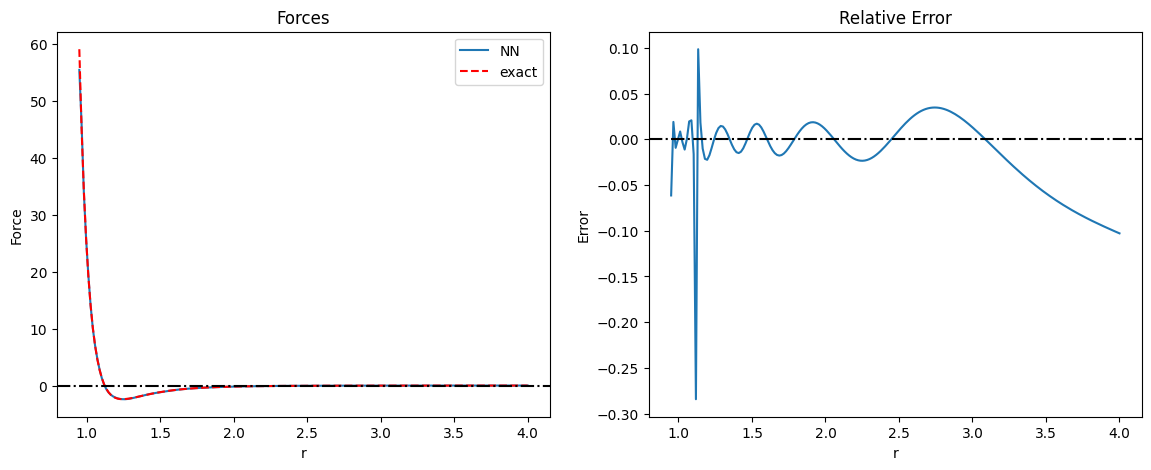

In [108]:
# using automatic differentiation
F_nn = -torch.autograd.grad(
    outputs=U_nn,
    inputs=r,
    create_graph=True,
    grad_outputs=torch.ones_like(U_nn)
)[0]

plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.plot(r.flatten().detach(),F_nn.flatten().detach(),label = 'NN')
plt.plot(r.flatten().detach(),F_exact.flatten().detach(),label = 'exact',c='red',ls = '--')
plt.axhline(0,ls = '-.',c='k')
plt.title('Forces')
plt.xlabel('r')
plt.ylabel('Force')
plt.legend()

plt.subplot(1,2,2)
plt.plot(r.flatten().detach(),((F_nn-F_exact)/F_exact).flatten().detach())
plt.axhline(0,ls = '-.',c='k')
plt.title('Relative Error')
plt.xlabel('r')
plt.ylabel('Error')

plt.show()